In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable',
                      noise_model=get_sensitivity,
                      noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                      channels=["A","E"])

In [3]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_A_p=0.0
dev_B_p=0.0
dev_A_e=0.0
dev_B_e=0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_A_p,dev_B_p,dev_A_e,dev_B_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devAp":dev_A_p,
"devBp":dev_B_p,"devAe":dev_A_e,"devBe":dev_B_e}

emri_kwargs = {"T":T, "dt":dt}

In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

# SNR = sef.SNRcalc_SEF(*pars_list,**emri_kwargs,use_gpu=use_gpu)
# print("SNR: ", SNR)
     


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 109.44009585567285
calculating stable deltas...
Gamma_ii for m1: 14237.901780049913
Gamma_ii for m1: 14237.900157752314
Gamma_ii for m1: 14237.90218806502
Gamma_ii for m1: 14237.897178215955
Gamma_ii for m1: 14237.877228093508
Gamma_ii for m1: 14237.910026528289
Gamma_ii for m1: 14237.88633218179
Gamma_ii for m1: 14237.853297452728
Gamma_ii for m1: 14238.034423429574
Gamma_ii for m1: 14237.810117944782
Gamma_ii for m1: 14238.066647776643
Gamma_ii for m1: 14237.295399853576
Gamma_ii for m1: 14241.6711400819
Gamma_ii for m1: 14237.834604719681
Gamma_ii for m1: 14217.684709686755
Gamma_ii for m1: 14276.539722176201
[np.float64(1.1394219521101406e-07), np.float64(1.4259914690647686e-07), np.fl

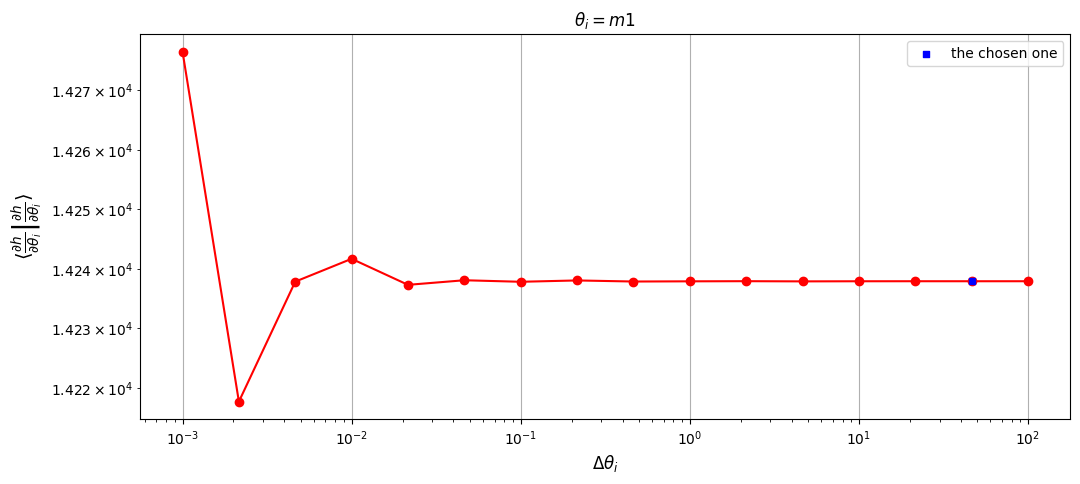

Gamma_ii for m2: 9078313020565.79
Gamma_ii for m2: 9078310540208.781
Gamma_ii for m2: 9078319746909.525
Gamma_ii for m2: 9078320319496.92
Gamma_ii for m2: 9078324104763.188
Gamma_ii for m2: 9078373819106.584
Gamma_ii for m2: 9078313805420.66
Gamma_ii for m2: 9078519581224.758
Gamma_ii for m2: 9078634805571.611
Gamma_ii for m2: 9078280096013.197
Gamma_ii for m2: 9078541104569.98
Gamma_ii for m2: 9076264686786.258
Gamma_ii for m2: 9087393893867.996
Gamma_ii for m2: 9079850773869.64
Gamma_ii for m2: 9033766411723.822
Gamma_ii for m2: 9162160295957.592
[np.float64(2.7321790732171374e-07), np.float64(1.0141414932289429e-06), np.float64(6.307195322261775e-08), np.float64(4.1695650253245345e-07), np.float64(5.47612869739449e-06), np.float64(6.610664404219422e-06), np.float64(2.2666229031792825e-05), np.float64(1.2691814278376058e-05), np.float64(3.9072330294130955e-05), np.float64(2.8750055077882055e-05), np.float64(0.0002508099821104595), np.float64(0.0012246863305053898), np.float64(0.00083

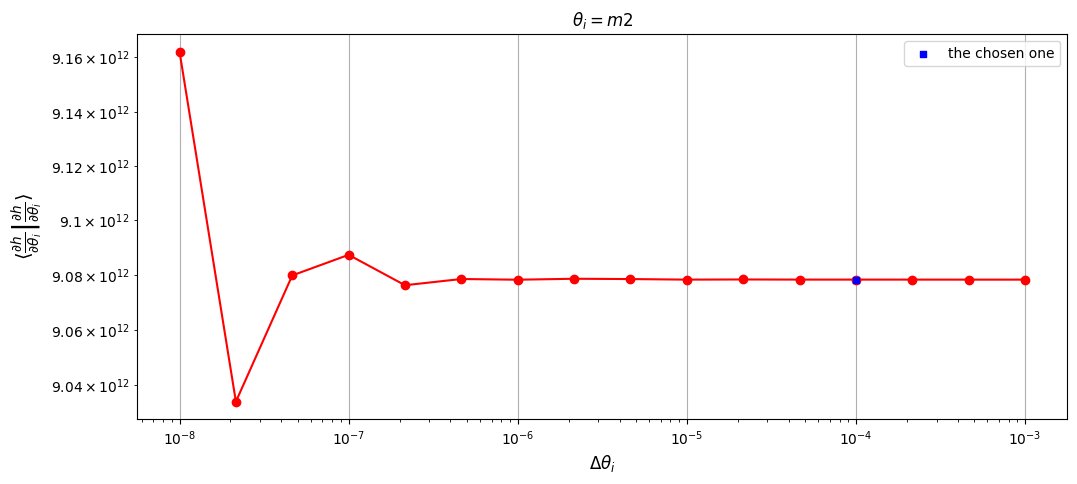

Gamma_ii for a: 1161739671934394.2
Gamma_ii for a: 1161739616116708.5
Gamma_ii for a: 1161739787911471.8
Gamma_ii for a: 1161738772326831.0
Gamma_ii for a: 1161739579954592.2
Gamma_ii for a: 1161742839485805.0
Gamma_ii for a: 1161747499912792.8
Gamma_ii for a: 1161741335489495.5
Gamma_ii for a: 1161616048300496.8
Gamma_ii for a: 1161657013682038.8
Gamma_ii for a: 1161702634039260.2
Gamma_ii for a: 1161629268432702.0
Gamma_ii for a: 1160145853726198.5
Gamma_ii for a: 1162063816501734.8
Gamma_ii for a: 1160955038498466.5
Gamma_ii for a: 1176136450686174.0
[np.float64(4.804664055150251e-08), np.float64(1.478771451555822e-07), np.float64(8.741936353866362e-07), np.float64(6.951882979501886e-07), np.float64(2.805725244833607e-06), np.float64(4.011566186369963e-06), np.float64(5.306192617010259e-06), np.float64(0.00010785593844201061), np.float64(3.526461000063551e-05), np.float64(3.9270253750632575e-05), np.float64(6.31575051971931e-05), np.float64(0.0012786450097968414), np.float64(0.00165

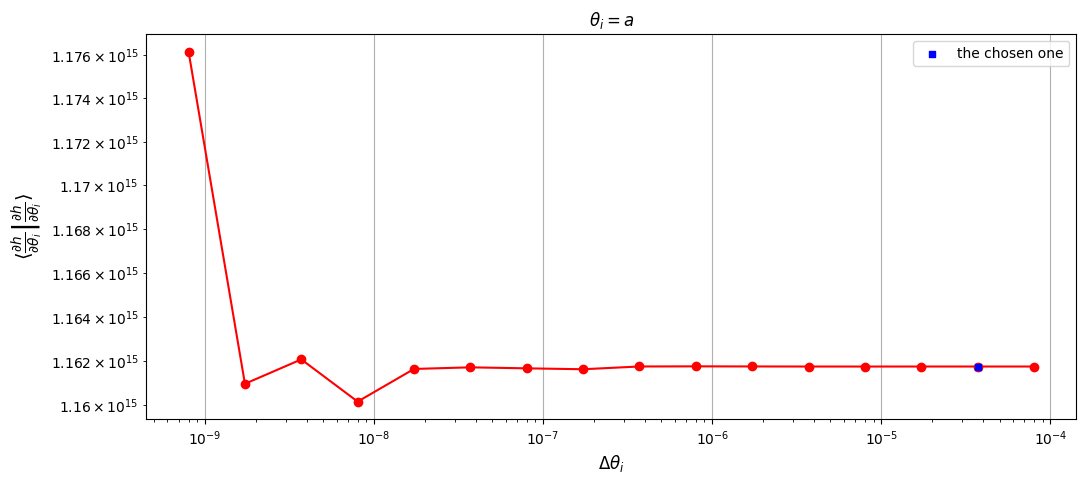

Gamma_ii for p0: 750491315056417.2
Gamma_ii for p0: 750491361067101.0
Gamma_ii for p0: 750491313359577.1
Gamma_ii for p0: 750491325779712.9
Gamma_ii for p0: 750491869170498.9
Gamma_ii for p0: 750490665025164.8
Gamma_ii for p0: 750492930530779.8
Gamma_ii for p0: 750489357048671.8
Gamma_ii for p0: 750487726515314.2
Gamma_ii for p0: 750504930214763.8
Gamma_ii for p0: 750508458378380.5
Gamma_ii for p0: 750537520274691.2
Gamma_ii for p0: 750502180806918.9
Gamma_ii for p0: 750720276058435.5
Gamma_ii for p0: 751540626142849.8
Gamma_ii for p0: 750677517502225.4
[np.float64(6.130741289890239e-08), np.float64(6.356838916820649e-08), np.float64(1.6549339510481707e-08), np.float64(7.240461999949408e-07), np.float64(1.604477430887996e-06), np.float64(3.018690147284586e-06), np.float64(4.761536022379925e-06), np.float64(2.172631609941096e-06), np.float64(2.2922833357772887e-05), np.float64(4.70103111745507e-06), np.float64(3.872144366628541e-05), np.float64(4.70877616030096e-05), np.float64(0.000290

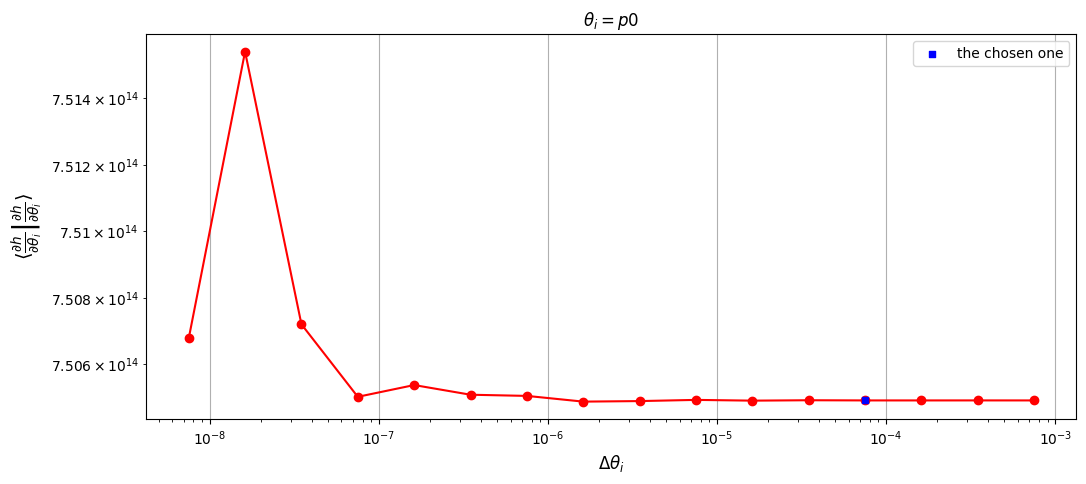

Gamma_ii for e0: 2443210386041492.0
Gamma_ii for e0: 2443209282335926.5
Gamma_ii for e0: 2443206429248905.0
Gamma_ii for e0: 2443205264814976.0
Gamma_ii for e0: 2443221748867604.0
Gamma_ii for e0: 2443205701545362.0
Gamma_ii for e0: 2443088680644948.0
Gamma_ii for e0: 2443117940041831.5
Gamma_ii for e0: 2443329643012087.5
Gamma_ii for e0: 2443327422910697.5
Gamma_ii for e0: 2441978680197935.0
Gamma_ii for e0: 2440981367652040.5
Gamma_ii for e0: 2445364982775118.0
Gamma_ii for e0: 2458668813608088.5
Gamma_ii for e0: 2447265303385991.5
Gamma_ii for e0: 2417866829732720.5
[np.float64(4.5174417659577603e-07), np.float64(1.1677633896768606e-06), np.float64(4.7660094130002727e-07), np.float64(6.746850806988808e-06), np.float64(6.56814210602482e-06), np.float64(4.7898752649088366e-05), np.float64(1.1976252314286152e-05), np.float64(8.664527558181501e-05), np.float64(9.086385104110312e-07), np.float64(0.000552315515159689), np.float64(0.0004085703230311039), np.float64(0.0017926220232788164), 

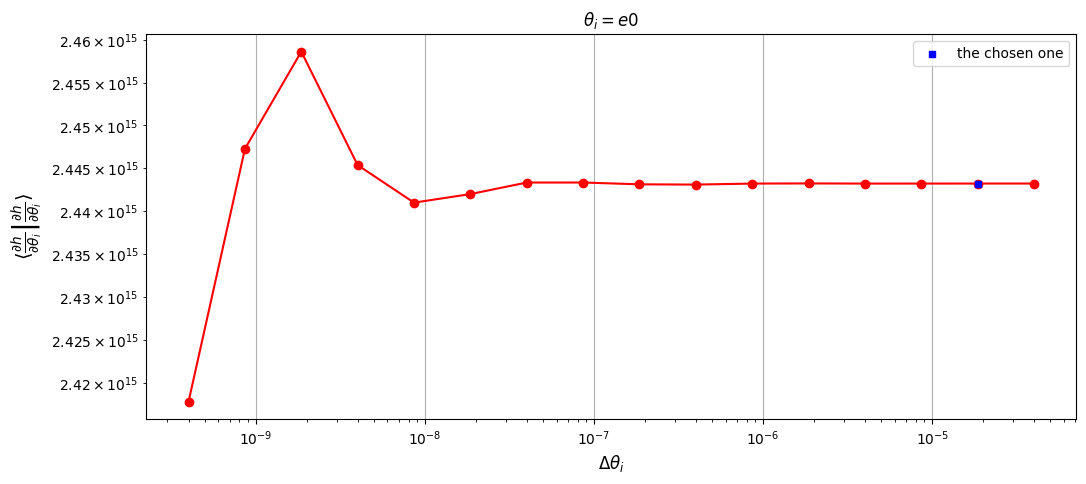

Gamma_ii for qS: 36773.70262139915
Gamma_ii for qS: 36773.7026829328
Gamma_ii for qS: 36773.70268306791
Gamma_ii for qS: 36773.702683068266
Gamma_ii for qS: 36773.70268306753
Gamma_ii for qS: 36773.70268306857
Gamma_ii for qS: 36773.70268306743
Gamma_ii for qS: 36773.70268305948
Gamma_ii for qS: 36773.70268307724
Gamma_ii for qS: 36773.702683094714
Gamma_ii for qS: 36773.702682987765
Gamma_ii for qS: 36773.702682947616
Gamma_ii for qS: 36773.70268310087
Gamma_ii for qS: 36773.70268343805
Gamma_ii for qS: 36773.70268428697
Gamma_ii for qS: 36773.702684422606
[np.float64(1.673305907337397e-09), np.float64(3.674018308740524e-12), np.float64(9.695023810021214e-15), np.float64(1.998362050637066e-14), np.float64(2.8293640914959636e-14), np.float64(3.106364771782378e-14), np.float64(2.1625838825215755e-13), np.float64(4.829704718419594e-13), np.float64(4.752540243194736e-13), np.float64(2.908309285383955e-12), np.float64(1.0917783955892364e-12), np.float64(4.167475234903996e-12), np.float64(9

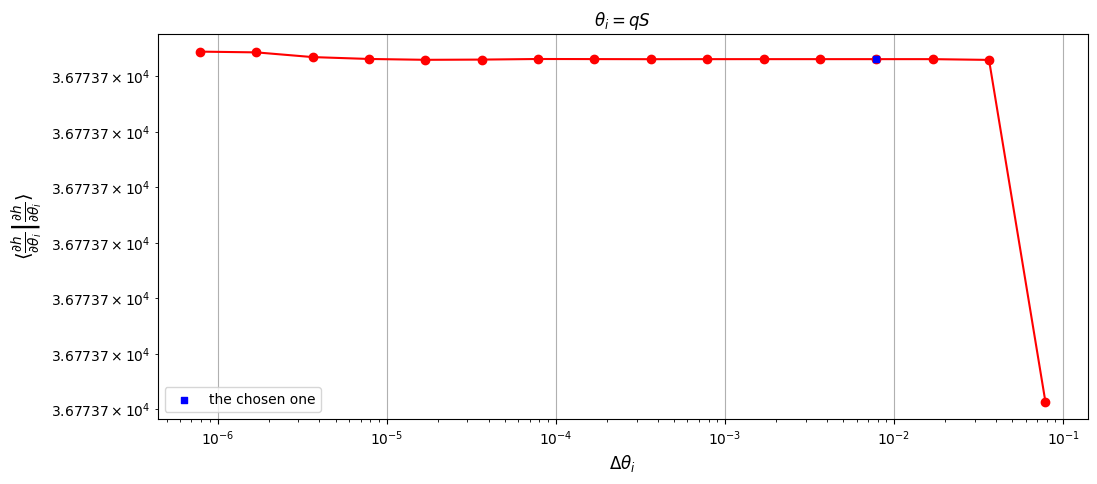

Gamma_ii for phiS: 709748.7617565944
Gamma_ii for phiS: 709748.7617330851
Gamma_ii for phiS: 709748.7617330332
Gamma_ii for phiS: 709748.761733033
Gamma_ii for phiS: 709748.761733033
Gamma_ii for phiS: 709748.761733033
Gamma_ii for phiS: 709748.761733033
Gamma_ii for phiS: 709748.7617330331
Gamma_ii for phiS: 709748.761733033
Gamma_ii for phiS: 709748.7617330333
Gamma_ii for phiS: 709748.7617330342
Gamma_ii for phiS: 709748.7617330328
Gamma_ii for phiS: 709748.7617330309
Gamma_ii for phiS: 709748.7617330282
Gamma_ii for phiS: 709748.76173299
Gamma_ii for phiS: 709748.7617330377
[np.float64(3.3123353788305464e-11), np.float64(7.315438410633355e-14), np.float64(3.280465654992537e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.6402328274962683e-16), np.float64(1.6402328274962685e-16), np.float64(4.920698482488803e-16), np.float64(1.148162979247386e-15), np.float64(1.9682793929955228e-15), np.float64(2.6243725239940375e-15), np.float64(3.772535503241443e-15), np.float

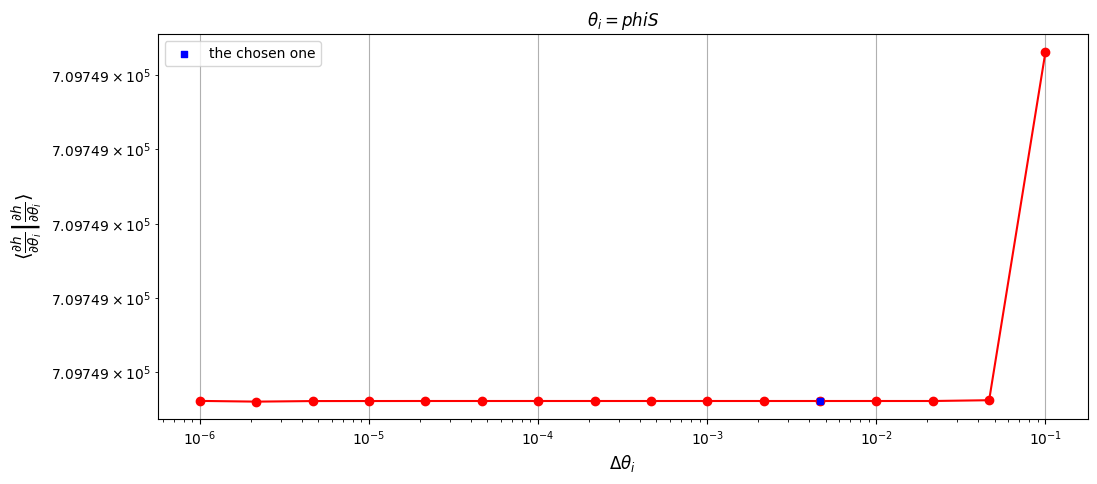

Gamma_ii for devAp: 172.41939554928948
Gamma_ii for devAp: 57.3399027209819
Gamma_ii for devAp: 30.6519120135244
Gamma_ii for devAp: 164.38474918160196
Gamma_ii for devAp: 2867.0066769587934
Gamma_ii for devAp: 4019.2111202509495
Gamma_ii for devAp: 227667.23667659817
Gamma_ii for devAp: 259598.67537685714
Gamma_ii for devAp: 240673.39443497255
Gamma_ii for devAp: 2993422.2888176665
Gamma_ii for devAp: 21118387.52309658
Gamma_ii for devAp: 223521091.56350166
Gamma_ii for devAp: 105678511.14398997
Gamma_ii for devAp: 1449012491.9404566
Gamma_ii for devAp: 9975293760.912134
Gamma_ii for devAp: 5259264236.758744
[np.float64(2.006970492926866), np.float64(0.8706794765586591), np.float64(0.8135355489719908), np.float64(0.9426632834507471), np.float64(0.2866742773194296), np.float64(0.9823461154142251), np.float64(0.12300308795452972), np.float64(0.07863470320978085), np.float64(0.9195992508861711), np.float64(0.8582551681304339), np.float64(0.9055194864369347), np.float64(1.1151044724593804

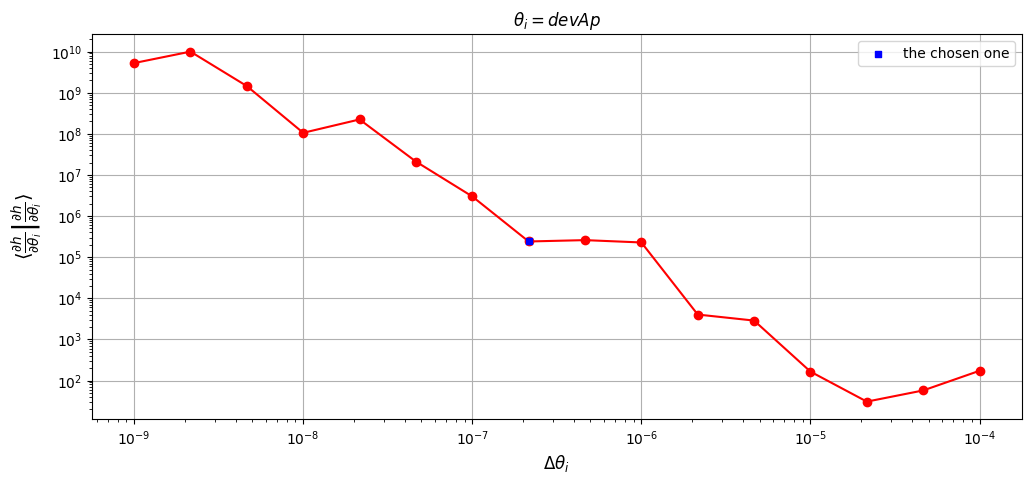

Gamma_ii for devBp: 6.527265832721175
Gamma_ii for devBp: 66.42598712462254
Gamma_ii for devBp: 35.110253056413356
Gamma_ii for devBp: 612.334476313658
Gamma_ii for devBp: 4073.6141255443827
Gamma_ii for devBp: 12902.793317999538
Gamma_ii for devBp: 38605.40091504264
Gamma_ii for devBp: 75960.29767908336
Gamma_ii for devBp: 1205375.670110272
Gamma_ii for devBp: 1072344.1726880542
Gamma_ii for devBp: 18423069.673898697
Gamma_ii for devBp: 7588262.478525338
Gamma_ii for devBp: 101965573.03896783
Gamma_ii for devBp: 1787639817.9122066
Gamma_ii for devBp: 15328460777.270966
Gamma_ii for devBp: 4344419887.770751
[np.float64(0.9017362614352227), np.float64(0.8919256155144386), np.float64(0.9426616425915095), np.float64(0.8496827491651955), np.float64(0.6842843231580213), np.float64(0.6657775074945033), np.float64(0.4917686989834805), np.float64(0.9369820550035374), np.float64(0.12405671687360102), np.float64(0.9417934040488745), np.float64(1.4278376935478565), np.float64(0.9255801516887925),

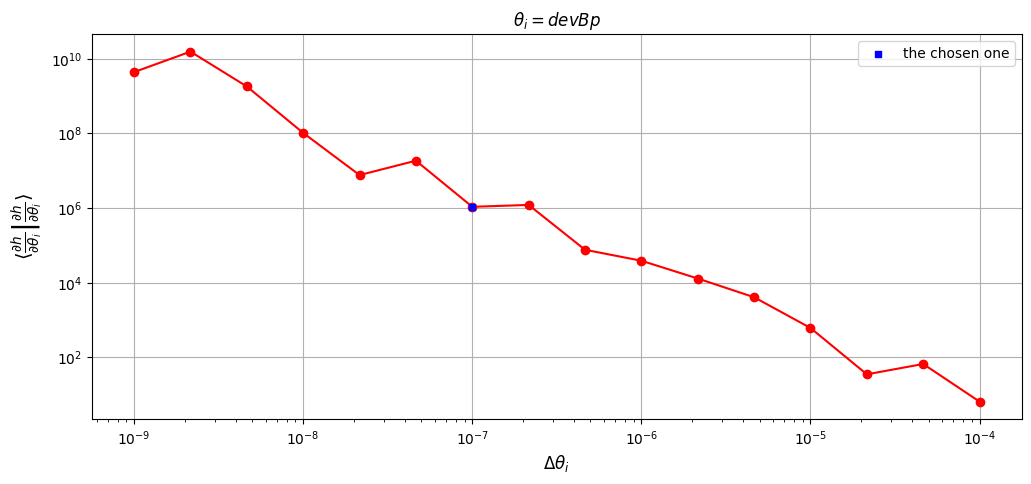

Gamma_ii for devAe: 1.0506858325304471
Gamma_ii for devAe: 11.592067608341743
Gamma_ii for devAe: 105.15039092292659
Gamma_ii for devAe: 114.54164669088907
Gamma_ii for devAe: 247.75715870140544
Gamma_ii for devAe: 43766.03940969721
Gamma_ii for devAe: 5312.900416158096
Gamma_ii for devAe: 163704.85916457698
Gamma_ii for devAe: 111151.62887058618
Gamma_ii for devAe: 3737375.02411646
Gamma_ii for devAe: 87494748.80686039
Gamma_ii for devAe: 85357800.03348577
Gamma_ii for devAe: 119379946.8835695
Gamma_ii for devAe: 4671062587.394962
Gamma_ii for devAe: 10259554337.901358
Gamma_ii for devAe: 14631071983.83442
[np.float64(0.9093616541906324), np.float64(0.889757256187107), np.float64(0.08198987913371321), np.float64(0.537685823928367), np.float64(0.9943390546176196), np.float64(7.237692405562842), np.float64(0.967545860011297), np.float64(0.4728066590475117), np.float64(0.9702594392713203), np.float64(0.9572845790738083), np.float64(0.025035190369670897), np.float64(0.28499046731244826), 

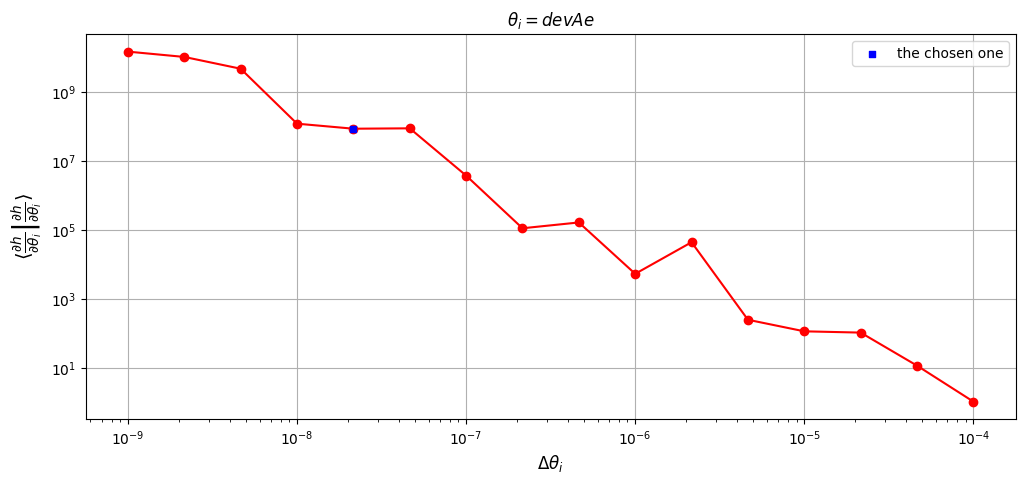

Gamma_ii for devBe: 13.930831629681125
Gamma_ii for devBe: 13.680633507967594
Gamma_ii for devBe: 76.70163178997731
Gamma_ii for devBe: 201.3377322632503
Gamma_ii for devBe: 1186.095531356578
Gamma_ii for devBe: 31431.60935086237
Gamma_ii for devBe: 119285.56046513752
Gamma_ii for devBe: 61868.934032237565
Gamma_ii for devBe: 382415.9000977009
Gamma_ii for devBe: 733273.5734790051
Gamma_ii for devBe: 31074518.38657531
Gamma_ii for devBe: 82744403.37858577
Gamma_ii for devBe: 313643798.95076305
Gamma_ii for devBe: 377546655.22025186
Gamma_ii for devBe: 170007062.12994295
Gamma_ii for devBe: 359836.59081216523
[np.float64(0.01828848945977653), np.float64(0.8216382990986737), np.float64(0.6190399537743404), np.float64(0.8302516728707565), np.float64(0.9622642443116252), np.float64(0.7365011387103421), np.float64(0.9280364585396335), np.float64(0.8382155814744338), np.float64(0.4784812736625233), np.float64(0.9764027373053096), np.float64(0.6244517197809974), np.float64(0.7361835188344493)

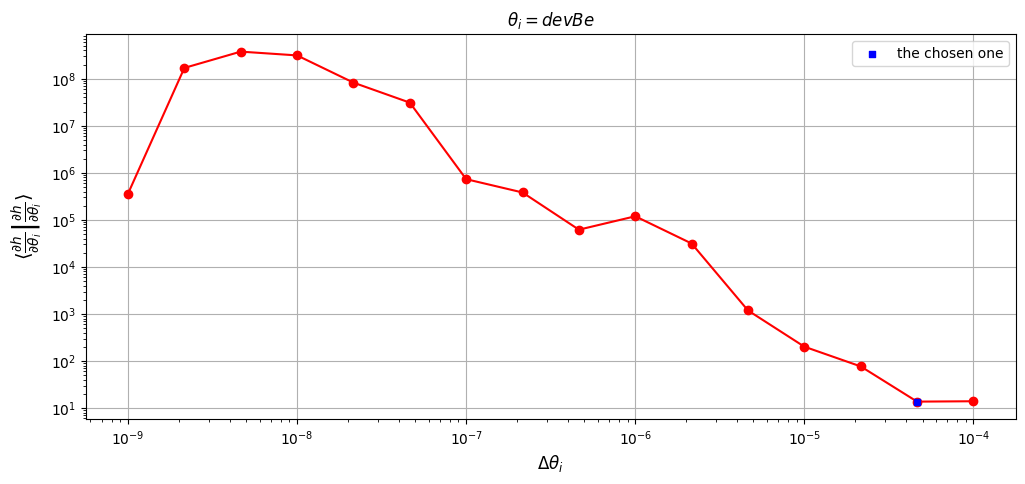

stable deltas: {'m1': 46.4158883361278, 'm2': 0.0001, 'a': 3.713271066890227e-05, 'p0': 7.500000000000001e-05, 'e0': 1.8566355334451135e-05, 'qS': 0.007853981633974485, 'phiS': 0.004641588833612782, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devAp': 2.1544346900318867e-07, 'devBp': 1e-07, 'devAe': 2.1544346900318866e-08, 'devBe': 4.641588833612782e-05}
Time taken to compute stable deltas is 85.62458086013794 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 7.33175802230835 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devAp','devBp','devAe','devBe']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [6]:
Fisher=Fisher[-1]

In [7]:
from stableemrifisher.utils import fishinv
J = np.eye(len(Fisher))
J[0,0] = m1
Fisher_lnM = J.T @ Fisher @ J
Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)
Fisher_inv = J.T @ Fisher_lnM_inv @ J
pd.DataFrame(np.matmul(Fisher_lnM,Fisher_lnM_inv))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.000000e+00,1.343771e-09,3.884774e-10,-1.463372e-09,-6.093701e-11,-8.456921e-11,1.977665e-09,-3.548373e-07,1.989696e-07,-3.585027e-08,-3.147604e-09,2.503865e-09,-6.623858e-06
1,-2.645215e-11,1.000000e+00,-7.218187e-12,5.376378e-11,-1.639064e-12,1.542784e-11,-3.960171e-11,1.718534e-08,5.743619e-10,1.466144e-10,3.239400e-10,6.305992e-11,1.748065e-07
2,5.244175e-10,8.572372e-10,1.000000e+00,-1.279203e-09,-7.218925e-11,-5.771431e-10,1.290461e-09,-5.108712e-07,2.300472e-08,-3.733561e-08,4.297378e-10,1.068039e-09,-6.172173e-07
3,2.824895e-10,3.501195e-10,1.145485e-10,1.000000e+00,-5.452911e-11,-2.301410e-10,5.205952e-11,-3.987012e-07,1.271342e-07,1.013875e-09,6.131875e-09,5.551507e-10,-1.571386e-06
4,5.611237e-10,1.258521e-09,2.550661e-10,-1.303799e-09,1.000000e+00,-8.909501e-11,8.332399e-10,-4.293811e-07,4.743556e-08,-1.134473e-08,1.005480e-08,-3.624287e-10,-6.585538e-06
5,-1.901332e-15,1.273304e-15,-6.481622e-16,5.347490e-15,2.242163e-16,1.000000e+00,-2.501149e-15,2.022087e-12,-2.031026e-13,1.211575e-13,1.907852e-14,-8.579601e-15,1.194350e-11
6,2.483522e-15,-7.021358e-15,4.352938e-15,-4.841221e-14,-2.589486e-16,-3.868523e-15,1.000000e+00,-5.430486e-12,2.595615e-12,-7.661685e-13,1.541756e-15,-1.498165e-14,-8.921506e-11
7,-1.787930e-15,-1.940903e-16,3.205531e-16,6.523487e-15,1.169978e-16,1.776759e-15,-8.986668e-15,1.000000e+00,-8.107387e-14,1.899289e-14,-2.237091e-14,1.943875e-15,2.309542e-11
8,-5.684455e-16,-1.466716e-15,-2.185792e-16,3.430415e-15,4.903180e-17,7.728956e-16,-4.995643e-15,6.160277e-13,1.000000e+00,2.451027e-14,-1.464890e-14,-3.396435e-15,2.081398e-12
9,-2.295692e-15,1.233823e-14,-4.161261e-16,1.922903e-14,9.398038e-17,3.109221e-15,-1.378658e-14,1.938834e-12,-6.082231e-13,1.000000e+00,1.444856e-14,-1.799821e-15,5.394220e-11


In [8]:
print(np.linalg.cond(Fisher_lnM))
np.sum(np.matmul(Fisher_lnM,Fisher_lnM_inv))


4.05944805008469e+16


np.float64(12.999983434637027)

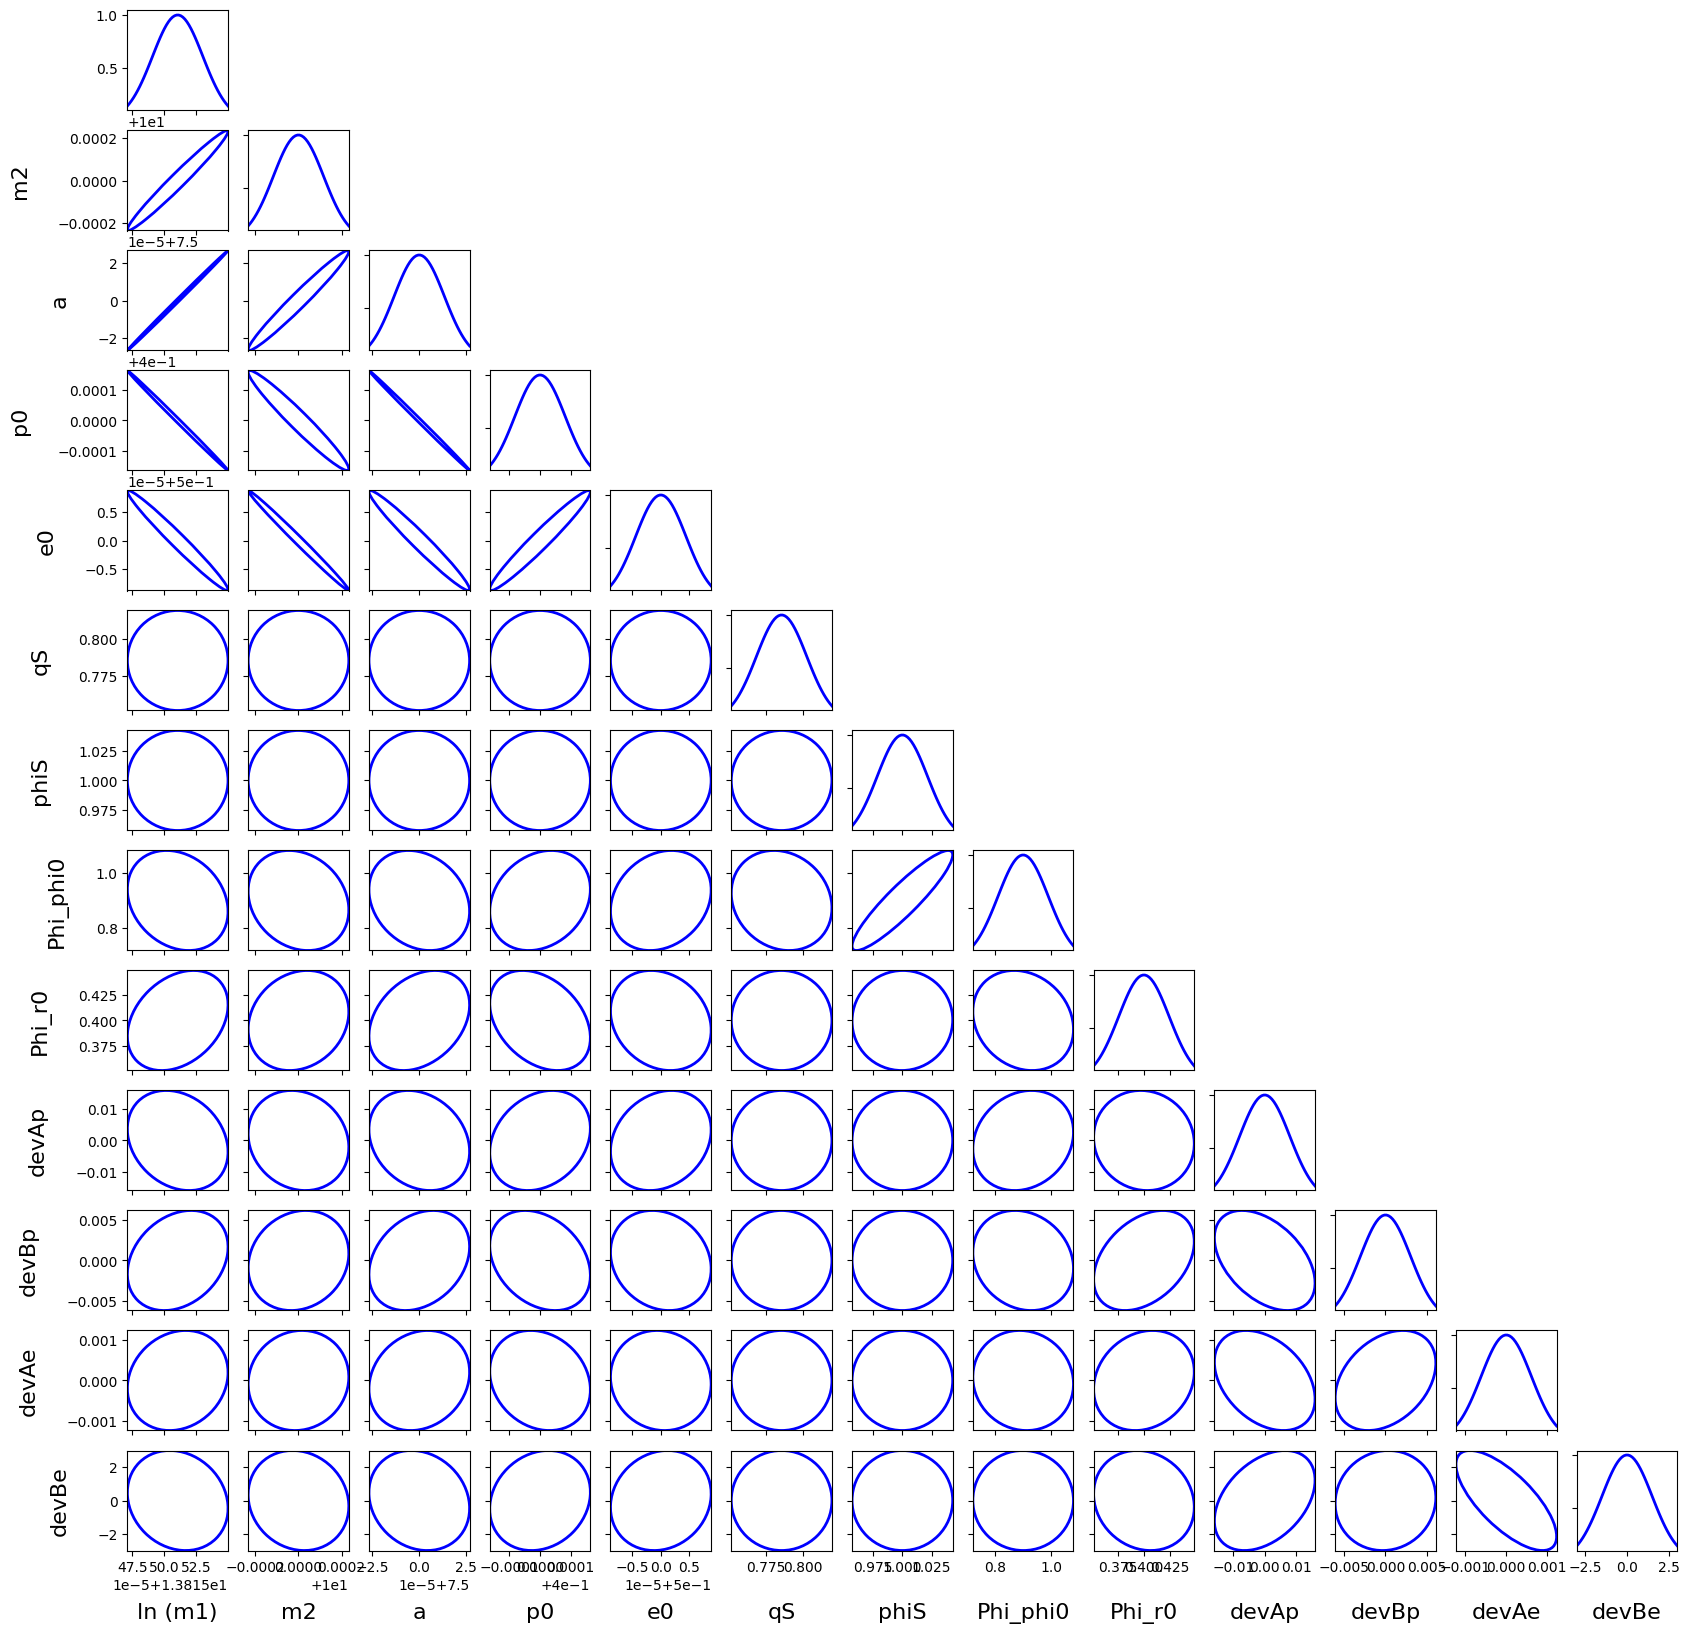

In [9]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [np.log(m1), m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,dev_A_p,dev_B_p,dev_A_e,dev_B_e]
param_names = ["ln (m1)",'m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devAp','devBp','devAe','devBe']
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
covariance = Fisher_lnM_inv

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)